# Module 3.3 — Notebook B: Improve the baseline

In **Notebook A** you evaluated whether Candlekeep’s routing prototype was strong enough for the next MVP step.

Here you take the next step:

> If the baseline is weak, can we improve it in practical ways?

You will try realistic levers: 
- **better prompt design**, 
- **few-shot examples**, 
- an **optional multi-model comparison** with the improved prompt, 
- and **deeper diagnostics**.

The goal is not perfect scores. The goal is to see **what actually helps**, what **trade-offs** appear (cost, latency, safety), and whether the prototype is moving closer to MVP viability.

## What this notebook explores

This notebook focuses on **improvement**, not initial validation.

1. **Prompt refinement** — Can clearer instructions improve routing quality?
2. **Few-shot learning** — Do labeled examples help the model route better?
3. **Trade-offs** — Do improvements change cost or latency?
4. **Diagnostics** — Where does the model still fail, and why?

Assume you have completed Notebook A (or at least have a comparable baseline). You’ll use the **same dataset** and compare every change to that reference.

## Environment

- **Colab / remote:** uncomment the GitHub install line below (restart the runtime if prompted).
- **Local (repo):** uncomment the editable install from the repo root, or ensure `src/` is on `PYTHONPATH`.
- **Progress:** evaluations use **tqdm**; in Jupyter, `ipywidgets` (e.g. `uv sync --extra dev`) gives the widget progress bar.

Keep your API key in **Secrets** (Colab) or **`.env`** — never commit real keys.

```python
# Local dev (repo root) — uncomment if working from a local clone:
%pip install -q -e .
```

In [73]:
# Colab / remote — uncomment if running in Colab or a fresh environment:

%pip install -q git+https://github.com/mnrozhkov/ai_leader.git

/Users/mnrozhkov/dev/ai-leader/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


## Step 1 — Configure the improvement experiment

Use the same setup style as Notebook A: one API key, one primary model, and clear defaults.

In this step, you define:
- **candidate models** (for optional comparison later),
- the **baseline prompt** vs **improved prompt**,
- and the **few-shot values** to test.

Keep the first pass simple: one model, deterministic temperature (`0.0`), and fixed monthly volume for cost projection.

This notebook uses async evaluation helpers, so cells that run evaluations use `await`.

In [ ]:
# %load_ext autoreload
# %autoreload 2
%matplotlib inline

import os
import sys
from pathlib import Path

import pandas as pd
from dotenv import load_dotenv

_cwd = Path.cwd().resolve()
ROOT = _cwd if (_cwd / "src" / "ai_leader").is_dir() else _cwd.parent
if (ROOT / "src" / "ai_leader").is_dir() and str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from ai_leader import (  # noqa: E402
    DEFAULT_SYSTEM_PROMPT,
    IMPROVED_SYSTEM_PROMPT,
    Thresholds,
    analyze_high_confident_errors,
    create_client,
    evaluate_decision,
    evaluate_model_on_dataframe_async,
    load_and_validate_dataset,
    prepare_mistake_examples,
    recommend_new_labels,
)
from ai_leader.ablation import (  # noqa: E402
    FewShotAblationConfig,
    prepare_few_shot_ablation_slice,
    run_few_shot_ablation_async,
)
from ai_leader.config import DEFAULT_MAX_CONCURRENCY  # noqa: E402
from ai_leader.reporting import (  # noqa: E402
    display_evaluation_with_department_mistakes,
    display_high_confident_errors,
    display_mvp_decision,
    display_run_comparison_table,
    plot_latency_for_n_shots,
    plot_metrics_for_n_shot,
)

load_dotenv(ROOT / ".env" if (ROOT / ".env").is_file() else ".env", override=False)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


True

### Settings

This notebook calls the Nebius inference API (**Token Factory**, OpenAI-compatible).  
Get your key at: https://studio.nebius.ai -> Settings -> API Keys (or https://tokenfactory.nebius.com).  
Store it as a Colab Secret named `NEBIUS_API_KEY`, or add it to a local `.env` file.  
Do **not** paste a real key directly into the notebook — the cell below prompts you interactively as a fallback only.

After the setup cell runs, `!env | grep NEBIUS_API_KEY` can show the key in the process environment (the cell copies it into `os.environ` for this session).

**401 / Couldn't authenticate:** use a Nebius **inference** API key (not an OpenAI key). The library default is the **global** Token Factory URL (`https://api.tokenfactory.nebius.com/v1/`). If your key is tied to a **regional** host (EU or US-Central), set `TOKENFACTORY_BASE_URL` accordingly (see commented lines in the settings code cell) or see [Nebius API authentication](https://docs.nebius.com/studio/api/authentication).


In [75]:
# Colab: use Secrets / env, or paste when prompted (fallback).

api_key = os.getenv("NEBIUS_API_KEY") or os.getenv("OPENAI_API_KEY") or ""
if not api_key:
    api_key = input("Paste Nebius API key (or set env): ").strip()
if api_key:
    os.environ["NEBIUS_API_KEY"] = api_key

# Select the best from from Notebook A
MODEL_TO_EVALUATE = "openai/gpt-oss-120b"
client = create_client(api_key, model=MODEL_TO_EVALUATE)

# Dataset URL
DATASET_URL = os.getenv(
    "AI_LEADER_DATASET_PATH",
    "https://docs.google.com/spreadsheets/d/e/2PACX-1vSU5zvx8wgk9FMEcRGlCtXkE4_T90OgsrqU4QPNZC478Rsp5JEBEEUjvlMkY3iMoiAmpa1zQ5QFkgT5/pub?output=csv",
)

# Evaluation settings
TEMPERATURE = 0.1
MONTHLY_MESSAGES = 20_000
N_SHOT_VALUES = [0, 2, 4, 8, 16]

DECISION_THRESHOLDS = Thresholds(
    department_accuracy_pass=0.85,
    category_accuracy_pass=0.85,
    unsafe_auto_route_rate_pass=0.03,
    monthly_cost_usd_pass=1_000.0,
    p95_latency_ms_pass=5_000.0,
)

### Load the dataset

Load the **same labeled evaluation dataset** used in Notebook A (same default URL in Settings, or the same `AI_LEADER_DATASET_PATH` if you pointed it at a local `.csv`).

Reusing the same data is important: it makes baseline vs improved comparisons meaningful instead of mixing dataset effects with model/prompt effects.

In [76]:
df = load_and_validate_dataset(DATASET_URL)
print(f"Rows loaded: {len(df)}")
df.head(3)

Rows loaded: 100


,Request Text,Submission Channel,Related to order,Order ID,Category,Routing to Department,Timestamp,Order History,row_id
0,My Autumn Oak table arrived with a cracked leg...,Email,True,CK-8821,Order Issue,Returns,2025-10-01 09:12:00,2025-09-24 — Order placed | 2025-09-25 — Shipp...,0
1,I need to change my address for order CK-9902....,Chat,True,CK-9902,Delivery,Logistics,2025-09-19 14:00:00,2025-09-12 — Order placed | 2025-09-14 — Shipp...,1
2,Where is my package? The tracking says DPD has...,Social,True,CK-1102,Delivery,Logistics,2025-10-01 10:15:00,2025-09-24 — Order placed | 2025-09-26 — Shipp...,2


**Optional:** department distribution in gold labels.

## Step 2 — Baseline reference run *(H2 / H6 / H7)*

Run the baseline prompt first; this is the reference point for all later comparisons.


In [77]:
baseline_run = await evaluate_model_on_dataframe_async(
    df=df,
    model=MODEL_TO_EVALUATE,
    client=client,
    system_prompt=DEFAULT_SYSTEM_PROMPT,
    temperature=TEMPERATURE,
    monthly_messages=MONTHLY_MESSAGES,
)

Running openai/gpt-oss-120b:   0%|          | 0/100 [00:00<?, ?row/s]

Confirm **misroute rate**, **department accuracy**, **safety**, **cost**, and **latency** before changing anything.

In [78]:
baseline_decision = evaluate_decision(
    baseline_run,
    thresholds=DECISION_THRESHOLDS,
)

display_mvp_decision(decision=baseline_decision)

,Dimension,Status,Value,Pass threshold (≤)
0,Department Accuracy,fail,0.590,0.85
1,Category Accuracy,fail,0.640,0.85
2,Unsafe Auto Route Rate,fail,0.370,0.03
3,Monthly Cost Usd,pass,3.333,1000.00
4,P95 Latency Ms,pass,2642.310,5000.00


> **Expected:** The baseline will likely fail one or more dimensions. That is the starting point, not the verdict.
> Note which dimensions fail and use that to decide which improvement to try first:
> - Quality FAIL -> Step 4 (prompt from mistakes) is the highest-leverage next step
> - Safety FAIL with high confidence coverage -> confidence is likely poorly calibrated; inspect **high-confidence errors** (new cell in Step 4) before re-testing
> - Cost FAIL -> consider a lighter model (optional Step 5 extension)
>
> **Confidence-calibration prompting techniques (practical):**
> - Add a clear confidence rubric (High only when label is unambiguous and evidence is explicit).
> - Require `Medium` for borderline routing and `Low` when key evidence is missing or conflicting.
> - Add explicit "do-not-use High when ..." rules (cross-department overlap, vague intent, missing order context).
> - Include a few contrastive examples: similar tickets where one is High-correct and one is Medium/Low-review.

## Step 3 — Improve prompt (compare with baseline)

Run baseline and improved prompts on the same setup, then compare improved vs baseline.


Run the improved prompt against the same evaluation setup as baseline so changes are attributable to prompt quality, not to data or threshold changes.

In [79]:
improved_prompt_run = await evaluate_model_on_dataframe_async(
    df=df,
    model=MODEL_TO_EVALUATE,
    client=client,
    system_prompt=IMPROVED_SYSTEM_PROMPT,
    temperature=TEMPERATURE,
    monthly_messages=MONTHLY_MESSAGES,
)

Running openai/gpt-oss-120b:   0%|          | 0/100 [00:00<?, ?row/s]

In [80]:
improved_prompt_decision = evaluate_decision(
    improved_prompt_run,
    thresholds=DECISION_THRESHOLDS,
)

display_mvp_decision(decision=improved_prompt_decision)

,Dimension,Status,Value,Pass threshold (≤)
0,Department Accuracy,fail,0.700,0.85
1,Category Accuracy,fail,0.830,0.85
2,Unsafe Auto Route Rate,fail,0.280,0.03
3,Monthly Cost Usd,pass,4.635,1000.00
4,P95 Latency Ms,pass,2364.467,5000.00


In [81]:
_ = display_run_comparison_table(
    baseline=baseline_run,
    new=improved_prompt_run,
    eval_df=df,
    new_label="Improved prompt",
    show_all=False,
)

,baseline,Improved prompt,delta_vs_baseline
department_accuracy,0.59,0.7,0.110
category_accuracy,0.64,0.83,0.190
unsafe_auto_route_rate,0.37,0.28,-0.090
monthly_cost_usd,3.333,4.635,1.302
p95_latency_ms,2642.31,2364.467,-277.843


## Step 4 — Analyze mistakes and fix annotations (compare with baseline)

Based on Step 3 results:
1) analyze mistakes,
2) inspect high-confidence errors,
3) apply annotation fixes via `revised_labels`,
4) compare the revised run with baseline.


In [82]:
mistake_examples = await prepare_mistake_examples(
    eval_df=df,
    predictions=improved_prompt_run.predictions,
    max_per_type=3,
)

display(mistake_examples.head(10))

,type,request_text,gold_category,predicted_category,gold_department,predicted_department
0,category,Website is crashing on the payment screen.,General Feedback,Payment,Product Team,Customer Support
1,category,I am going to sue your company if you don't fi...,Delivery,Order Issue,Logistics,Returns
2,category,Refund the holiday wreath. It looks cheap.,Order Issue,Payment,Returns,Customer Support
3,department,The toaster oven sparked when I plugged it in....,Order Issue,Order Issue,Product Team,Returns
4,department,Instructions for the Lumina lamp are missing f...,Order Issue,Order Issue,Product Team,Returns
5,department,Website is crashing on the payment screen.,General Feedback,Payment,Product Team,Customer Support


#### High-confidence errors (calibration check)

Review cases where the model said `Confidence == "High"` but routed to the wrong department.
If this set is large, confidence is likely **poorly calibrated** (the model is overconfident).

Use these rows to tighten confidence rules before re-testing.
Also note: some examples can be **data-label issues** (ambiguous or mis-annotated gold labels), so treat this review as model+data quality learning.

In [83]:
high_conf_errors_df = display_high_confident_errors(
    eval_df=df,
    predictions=improved_prompt_run.predictions,
    max_rows=10,
)

High-confidence department errors: 28
Error rate within High-confidence predictions: 28.6%
Reminder: some rows may indicate labeling ambiguity/data issues, not only model issues.


,row_id,Request Text,Category,Department,Predicted Category,Predicted Department,Confidence
4,4,The toaster oven sparked when I plugged it in....,Order Issue,Product Team,Order Issue,Returns,High
8,8,Instructions for the Lumina lamp are missing f...,Order Issue,Product Team,Order Issue,Returns,High
13,13,Website is crashing on the payment screen.,General Feedback,Product Team,Payment,Customer Support,High
19,19,I am going to sue your company if you don't fi...,Delivery,Logistics,Order Issue,Returns,High
23,23,Refund the holiday wreath. It looks cheap.,Order Issue,Returns,Payment,Customer Support,High
26,26,Package in rain rug ruined.,Delivery,Logistics,Order Issue,Returns,High
32,32,No refund received for return CK-9944.,Payment,Returns,Payment,Customer Support,High
33,33,Sage green curtains are actually grey.,Order Issue,Returns,General Feedback,Product Team,High
35,35,Order canceled without my permission.,Order Issue,Customer Support,Order Issue,Returns,High
37,37,Add one more lamp to order CK-1100.,Order Issue,Customer Support,Order Issue,Returns,High


#### Re-annotation candidates (top 10)

Export 10 high-confidence errors to `fixed-annotation.json` for manual review.
This creates a small queue of examples to verify/correct gold labels before re-testing.

- Allowed Department: Logistics, Customer Support, Product Team, Returns
- Allowed Category: Delivery, Order Issue, General Feedback, Payment

In [84]:
analyzed_high_conf_df = analyze_high_confident_errors(high_conf_errors_df)

llm_review_df = await recommend_new_labels(
    analyzed_high_conf_df,
    client=client,
    model=MODEL_TO_EVALUATE,
)

revise_df = llm_review_df.loc[llm_review_df["Revise labels"]].head(10)
print(f"LLM relabel recommendations analyzed: {len(llm_review_df)}")
print(f"Rows flagged for revision: {int(llm_review_df['Revise labels'].sum())}")
with pd.option_context("display.max_colwidth", None):
    display(revise_df.head(3))

LLM relabel analysis:   0%|          | 0/10 [00:00<?, ?item/s]

LLM relabel recommendations analyzed: 10
Rows flagged for revision: 3


,row_id,Original request,category,department,recommendation,Revise labels
0,4,The toaster oven sparked when I plugged it in. This is a major safety issue!,Order Issue,Product Team,"Change category to General Feedback: The request reports a product safety defect, which is feedback about the product rather than an order problem, so the category should be updated while the department (Product Team) remains appropriate.",True
2,13,Website is crashing on the payment screen.,General Feedback,Product Team,"Change category to Payment: The request describes a website crash specifically on the payment screen, which is a payment-related issue rather than general feedback. The current department (Product Team) is appropriate for handling technical bugs.",True
7,33,Sage green curtains are actually grey.,Order Issue,Returns,"Change category to General Feedback and department to Product Team: The request is about a product color discrepancy, which is feedback on the product rather than an order or return issue.",True


Fix annotations for 10 items in the dataset

In [85]:
from ai_leader import apply_revised_labels

revised_labels = [
    {"row_id": 4, "new_category": "General Feedback"},
    {"row_id": 13, "new_category": "Payment"},
    {"row_id": 26, "new_department": "Returns"},
    {"row_id": 33, "new_category": "General Feedback", "new_department": "Product Team"},
    {"row_id": 40, "new_category": "Order Issue", "new_department": "Returns"},
    {"row_id": 57, "new_category": "General Feedback", "new_department": "Product Team"},
    {"row_id": 65, "new_category": "General Feedback"},
    {"row_id": 83, "new_category": "General Feedback", "new_department": "Product Team"},
    {"row_id": 88, "new_category": "Delivery", "new_department": "Logistics"},
    {"row_id": 90, "new_category": "General Feedback", "new_department": "Product Team"},
    {"row_id": 94, "new_department": "Logistics"},
    {"row_id": 95, "new_category": "Delivery", "new_department": "Logistics"},
    {"row_id": 99, "new_department": "Logistics"},
]

# Apply recommended labels
df = apply_revised_labels(df, revised_labels)

# Check that the labels were updated correctly
df.loc[df["row_id"] == 4, "Category"]

4    General Feedback
Name: Category, dtype: str

In [86]:
revised_labels_run = await evaluate_model_on_dataframe_async(
    df=df,
    model=MODEL_TO_EVALUATE,
    client=client,
    system_prompt=IMPROVED_SYSTEM_PROMPT,
    temperature=TEMPERATURE,
    monthly_messages=MONTHLY_MESSAGES,
)

Running openai/gpt-oss-120b:   0%|          | 0/100 [00:00<?, ?row/s]

In [87]:
revised_labels_decision = evaluate_decision(
    revised_labels_run,
    thresholds=DECISION_THRESHOLDS,
)

display_mvp_decision(decision=revised_labels_decision)

,Dimension,Status,Value,Pass threshold (≤)
0,Department Accuracy,fail,0.780,0.85
1,Category Accuracy,pass,0.870,0.85
2,Unsafe Auto Route Rate,fail,0.170,0.03
3,Monthly Cost Usd,pass,4.667,1000.00
4,P95 Latency Ms,pass,2749.581,5000.00


In [88]:
_ = display_run_comparison_table(
    baseline=improved_prompt_run,
    new=revised_labels_run,
    eval_df=df,
    new_label="Fix data annotation",
)

,baseline,Fix data annotation,delta_vs_baseline
department_accuracy,0.7,0.78,0.080
category_accuracy,0.83,0.87,0.040
unsafe_auto_route_rate,0.2,0.17,-0.030
monthly_cost_usd,4.635,4.667,0.032
p95_latency_ms,2364.467,2749.581,385.114


## Step 5 — Few-shot trade-offs *(H2 / H6 / H7, optional)*

This section runs a **few-shot ablation**: keep everything else fixed and vary only the number of examples (`n_shot`).

High-level logic:
- Build one fixed eval slice and one few-shot pool.
- For each `n_shot` value, take the first `n` examples from the same pool.
- Run evaluation on the same eval set and compare quality/cost/latency across runs.
- Pick the point where quality gains start to flatten relative to added cost/latency.

Important setup for this notebook:
- We run few-shot using the **default system prompt** (the one that performed poorly in baseline).
- We run it on the **dataset with revised labels** from Step 4.

Read this chart as:
- quality gain vs baseline,
- cost increase vs baseline,
- latency change vs baseline,
- and where returns start to flatten as `n_shot` grows.

Note: we use a dataset with updated labels here!

In [89]:
ablation_config = FewShotAblationConfig(
    best_model=MODEL_TO_EVALUATE,
    few_shot_counts=N_SHOT_VALUES,
    ablation_random_state=42,
    few_shot_pool_n=32,
    ablation_eval_n=68,
)

few_shot_pool_df, eval_df_fixed, few_shot_counts = prepare_few_shot_ablation_slice(
    df,
    config=ablation_config,
)

ablation_df, _phase2_predictions = await run_few_shot_ablation_async(
    few_shot_pool_df=few_shot_pool_df,
    eval_df_fixed=eval_df_fixed,
    few_shot_counts=few_shot_counts,
    best_model=MODEL_TO_EVALUATE,
    client=client,
    max_concurrency=DEFAULT_MAX_CONCURRENCY,
    system_prompt=DEFAULT_SYSTEM_PROMPT,
    temperature=TEMPERATURE,
    show_progress=True,
)

ablation_default_columns = [
    "n_shot",
    "department_accuracy",
    "category_accuracy",
    "cost_total_usd",
    "p95_latency_ms",
]
display(ablation_df[[c for c in ablation_default_columns if c in ablation_df.columns]])

Few-shot ablation slice: pool=32 rows, fixed eval=68 rows, model=openai/gpt-oss-120b


[Few-shot 1/5] gpt-oss-120b  n_shot=0  eval=68:   0%|          | 0/68 [00:00<?, ?row/s]

[Few-shot 2/5] gpt-oss-120b  n_shot=2  eval=68:   0%|          | 0/68 [00:00<?, ?row/s]

[Few-shot 3/5] gpt-oss-120b  n_shot=4  eval=68:   0%|          | 0/68 [00:00<?, ?row/s]

[Few-shot 4/5] gpt-oss-120b  n_shot=8  eval=68:   0%|          | 0/68 [00:00<?, ?row/s]

[Few-shot 5/5] gpt-oss-120b  n_shot=16  eval=68:   0%|          | 0/68 [00:00<?, ?row/s]

,n_shot,department_accuracy,category_accuracy,cost_total_usd,p95_latency_ms
0,0,0.558824,0.750000,0.011510,1914.485531
1,2,0.720588,0.647059,0.013388,2923.451077
2,4,0.750000,0.838235,0.013353,2598.863502
3,8,0.867647,0.911765,0.015408,2385.116787
4,16,0.779412,0.897059,0.023764,1885.795014


### Visualize few-shot trade-offs

Accuracy vs `n_shot`, cost, and latency. Interpret: where do gains **flatten**?

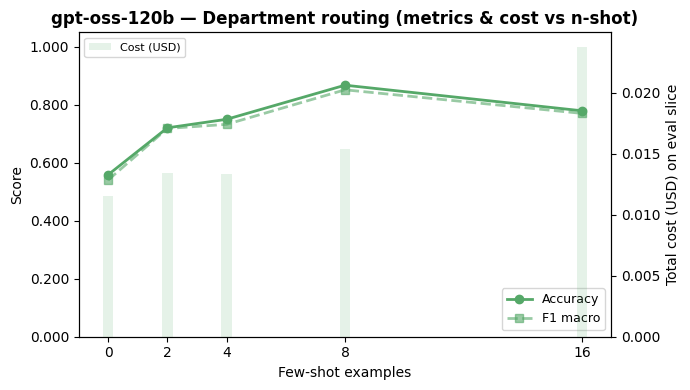

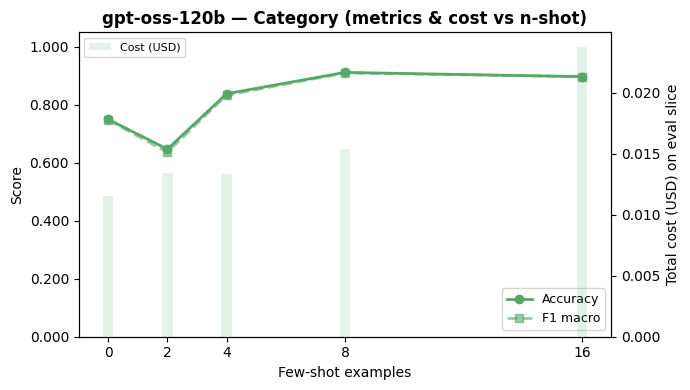

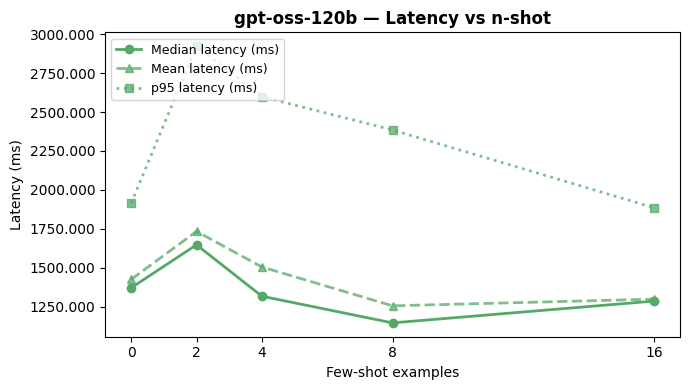

In [90]:
_ = plot_metrics_for_n_shot(ablation_df, best_model=MODEL_TO_EVALUATE)
_ = plot_latency_for_n_shots(ablation_df, best_model=MODEL_TO_EVALUATE)

### Run with optimal few-shot examples 

In [91]:
# Choose best n_shot from ablation (priority: department accuracy, then category accuracy).
best_n = 8
print(f"Selected best n_shot = {best_n}")

Selected best n_shot = 8


In [92]:
best_n_run = await evaluate_model_on_dataframe_async(
    df=df,
    model=MODEL_TO_EVALUATE,
    client=client,
    system_prompt=IMPROVED_SYSTEM_PROMPT,
    temperature=TEMPERATURE,
    monthly_messages=MONTHLY_MESSAGES,
)

Running openai/gpt-oss-120b:   0%|          | 0/100 [00:00<?, ?row/s]

In [93]:
best_n_decision = evaluate_decision(
    best_n_run,
    thresholds=DECISION_THRESHOLDS,
)

display_mvp_decision(decision=best_n_decision)

,Dimension,Status,Value,Pass threshold (≤)
0,Department Accuracy,fail,0.780,0.85
1,Category Accuracy,pass,0.870,0.85
2,Unsafe Auto Route Rate,fail,0.190,0.03
3,Monthly Cost Usd,pass,4.631,1000.00
4,P95 Latency Ms,pass,2732.085,5000.00


In [94]:
# Compare best n-shot with revised labels run

_ = display_run_comparison_table(
    baseline=revised_labels_run,
    new=best_n_run,
    eval_df=df,
    new_label=f"Few-shot best n={best_n}",
)

,baseline,Few-shot best n=8,delta_vs_baseline
department_accuracy,0.78,0.78,0.000
category_accuracy,0.87,0.87,0.000
unsafe_auto_route_rate,0.17,0.19,0.020
monthly_cost_usd,4.667,4.631,-0.036
p95_latency_ms,2749.581,2732.085,-17.496


### Deeper analysis

Use the diagnostics below to understand remaining failure modes (for example, recurring department confusions) and decide which combination of methods to apply next.

category_accuracy           0.870
category_f1_macro           0.872
department_accuracy         0.780
department_f1_macro         0.776
exact_route_match_rate      0.760
misroute_rate               0.220
row_count                 100.000


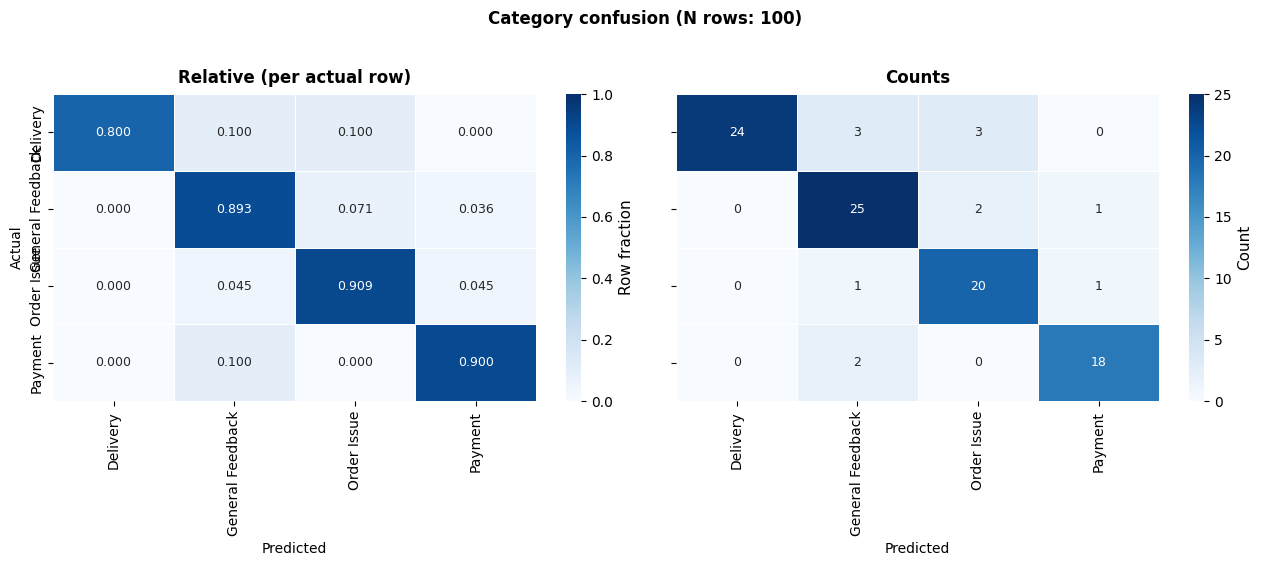

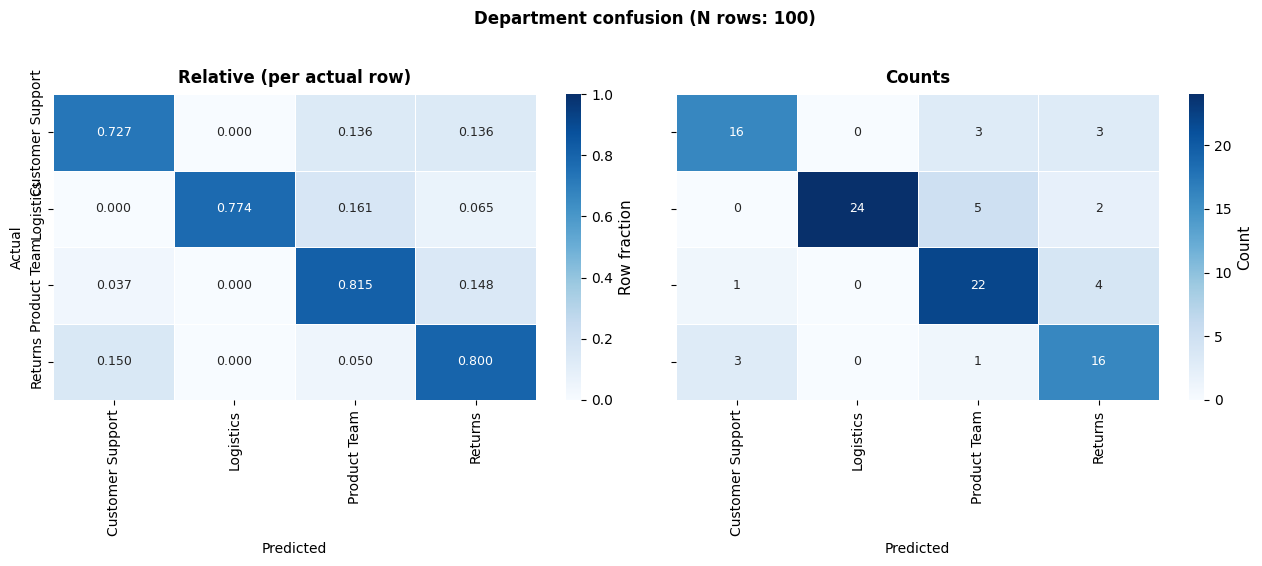

In [95]:
mistakes = display_evaluation_with_department_mistakes(
    eval_results=best_n_run,
    eval_df=df,
    max_rows=10,
)

## Summary 

We evaluated three levers:
1. **Prompt improvement** (error-driven prompt refinement).
2. **Data quality improvement** (targeted re-labeling for inconsistent/ambiguous rows).
3. **Few-shot examples** (ablation across multiple `n_shot` values).

Key takeaway:
- These levers are **not exclusive** and can be combined.
- In this notebook, prompt engineering and few-shot can be practical alternatives with similar quality gains.
- Data quality remains foundational: better labels improve every downstream approach.

How to report final results:
- Compare each approach against the same baseline.
- Highlight quality and safety movement first.
- Then report cost and latency trade-offs.
- Choose the configuration with the best quality/safety improvement for acceptable cost/speed.

---

*Disclaimer: This notebook is for learning and offline evaluation. Results depend on dataset scope, prompt choices, and model version/availability; validate with fresh runs before production decisions.*
